# Imports

In [2]:
import os, gc, csv, time, json, pickle
import numpy as np
import pandas as pd
from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

from transformers import (
    ViTModel, ViTImageProcessor,
    AutoModel, AutoImageProcessor,
)

from sklearn.metrics.pairwise import cosine_similarity

/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
from paths import EMBED_DIR, UNIMODAL_EVAL_DIR, VISION_EVAL_DIR, vision_emb_path

# Config

In [17]:
CURRENT_DATASET = "Flickr8k"
BASE_DIR = "TFE_Data"
RAW_DIR = os.path.join(BASE_DIR, "Features_RAW")
DATASETS_DIR = os.path.join(BASE_DIR, "Datasets")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

TOP_KS = [1, 5, 10, 50]
VISION_MODELS = ["ResNet50", "MobileNetV3", "ViT", "PVT"]


def ts():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

Using device: cuda


In [18]:
VISION_EVAL_DATASET_DIR = os.path.join(VISION_EVAL_DIR, CURRENT_DATASET)
os.makedirs(VISION_EVAL_DATASET_DIR, exist_ok=True)

# Dataset Loader

In [19]:
def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.where(norms == 0, 1e-9, norms)


# Performance

In [20]:
def recall_at_k_index(sim_matrix, k):
    N = sim_matrix.shape[0]
    ranks = np.argsort(-sim_matrix, axis=1)
    hits = [(ranks[i, :k] == i).any() for i in range(N)]
    return np.mean(hits)


In [24]:
results = []

for model in VISION_MODELS:
    # OLD PATH: emb_path = f"TFE_Data/Unimodal_Results/Flickr8k/vision/{model}/embeddings.npy"
    emb_path = vision_emb_path(CURRENT_DATASET, model)

    if not os.path.exists(emb_path):
        print(f"[WARNING] Missing embeddings for {model}, skipping.")
        continue

    print(f"\n[{ts()}] === MODEL: {model} ===")

    X = np.load(emb_path)
    X_norm = normalize_matrix(X)
    sim = cosine_similarity(X_norm)

    res = {
        "Dataset": CURRENT_DATASET,
        "Model": model,
        "Dim": X.shape[1],
    }

    for k in TOP_KS:
        res[f"Recall@{k}"] = recall_at_k_index(sim, k)

    results.append(res)

df = pd.DataFrame(results)

out_path = os.path.join(VISION_EVAL_DATASET_DIR, "vision_retrieval_results.csv")
df.to_csv(out_path, index=False)

print("Saved to:", out_path)



[2026-05-21 11:08:12] === MODEL: ResNet50 ===

[2026-05-21 11:08:17] === MODEL: MobileNetV3 ===

[2026-05-21 11:08:21] === MODEL: ViT ===

[2026-05-21 11:08:26] === MODEL: PVT ===
Saved to: TFE_Data/Evaluations/Unimodal/vision/Flickr8k/vision_retrieval_results.csv


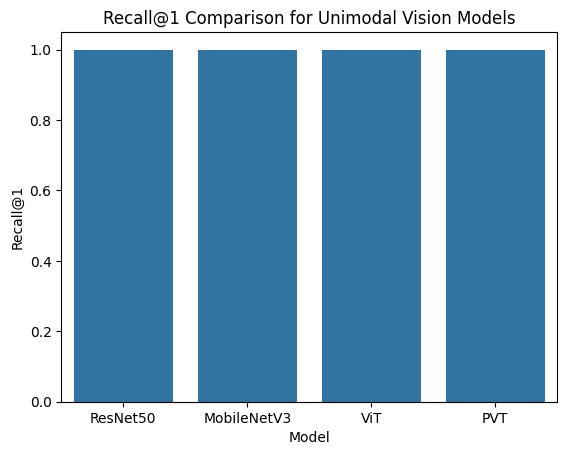

In [4]:
df = pd.read_csv("TFE_Data/Evaluations/Unimodal/vision/Flickr8k/vision_retrieval_results.csv")

sns.barplot(data=df, x="Model", y="Recall@1")
plt.title("Recall@1 Comparison for Unimodal Vision Models")
plt.show()


In [6]:
df = pd.read_csv("TFE_Data/Evaluations/Unimodal/vision/Flickr8k/vision_retrieval_results.csv")
df

,Dataset,Model,Dim,Recall@1,Recall@5,Recall@10,Recall@50
0,Flickr8k,ResNet50,2048,0.999876,1.0,1.0,1.0
1,Flickr8k,MobileNetV3,960,0.999876,1.0,1.0,1.0
2,Flickr8k,ViT,768,0.999876,1.0,1.0,1.0
3,Flickr8k,PVT,512,0.999876,1.0,1.0,1.0


In [31]:
eff_df = pd.read_pickle(os.path.join(EMBED_DIR, "global_unimodal_metrics.pkl"))
eff_vision = eff_df[eff_df["Modality"] == "vision"]
eff_vision = eff_vision.rename(columns={
    "Time_s": "Emb_Time_s"
})

eff_out_path = os.path.join(VISION_EVAL_DATASET_DIR, "vision_efficiency_results.csv")
eff_df.to_csv(eff_out_path, index=False)

print("Saved to:", eff_out_path)

eff_vision

Saved to: TFE_Data/Evaluations/Unimodal/vision/Flickr8k/vision_efficiency_results.csv


,Dataset,Modality,Model,Num_Samples,Emb_Time_s,Latency_s,Throughput_samples_per_s,Memory_MB
0,Flickr8k,vision,ResNet50,8091,18.159502,0.002244,445.551871,3624.875000
1,Flickr8k,vision,MobileNetV3,8091,12.114647,0.001497,667.869225,8.515625
2,Flickr8k,vision,ViT,8091,60.184088,0.007438,134.437529,5844.355469
3,Flickr8k,vision,PVT,8091,19.957821,0.002467,405.404981,6.582031
